<a href="https://colab.research.google.com/github/MrMehulMaurya/React_L1/blob/main/creative_module_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install mtcnn easyocr opencv-python-headless scikit-learn matplotlib lz4


In [2]:
import cv2
import easyocr
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from google.colab.patches import cv2_imshow
from google.colab import files
from mtcnn import MTCNN # <--- NAYA DEEP LEARNING MODEL

# Setup MTCNN Face Detector
print("Loading MTCNN Face Detector...")
face_detector = MTCNN()

# Load OCR
print("Loading OCR Model...")
reader = easyocr.Reader(['en'], gpu=True)
print("All Models Ready! ✅")

def calculate_text_area(result, img_area):
    text_area = 0
    for (bbox, text, prob) in result:
        (tl, tr, br, bl) = bbox
        width = int(br[0]) - int(tl[0])
        height = int(br[1]) - int(tl[1])
        text_area += (width * height)
    return (text_area / img_area) * 100

def get_dominant_colors(image, k=3):
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image_small = cv2.resize(image_rgb, (100, 100)).reshape((10000, 3))
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(image_small)
    return kmeans.cluster_centers_.astype(int)

# --- MTCNN DEEP LEARNING FACE COUNT ---
def count_faces_dl(image):
    # MTCNN ko RGB format chahiye
    img_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    # Detect faces
    faces = face_detector.detect_faces(img_rgb)
    return len(faces)

def run_creative_audit(image_path):
    print(f"\n--- Running Deep Learning Audit on: {image_path} ---")
    img = cv2.imread(image_path)
    img_area = img.shape[0] * img.shape[1]

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    brightness = np.mean(gray)

    text_results = reader.readtext(image_path)
    text_percentage = calculate_text_area(text_results, img_area)

    # Face check using MTCNN
    face_count = count_faces_dl(img)
    dominant_colors = get_dominant_colors(img)

    # Scoring Engine
    score = 10.0
    feedback = []

    if text_percentage > 20:
        score -= 3
        feedback.append(f"❌ Text is {text_percentage:.1f}% (Rule is <20%).")
    else:
        feedback.append(f"✅ Text is {text_percentage:.1f}% (Good).")

    if brightness < 80:
        score -= 2
        feedback.append(f"❌ Image is too dark (Brightness: {brightness:.1f}).")
    elif brightness > 220:
        score -= 1
        feedback.append(f"❌ Image is washed out (Brightness: {brightness:.1f}).")
    else:
        feedback.append(f"✅ Brightness is perfect ({brightness:.1f}).")

    if face_count > 0:
        score += 1
        feedback.append(f"✅ Found {face_count} human face(s) using MTCNN Deep Learning! Good for engagement.")
    else:
        score -= 1
        feedback.append("⚠️ No human face detected.")

    score = max(1.0, min(10.0, score))

    print(f"\n🎯 FINAL CREATIVE SCORE: {score}/10")
    print("\n📝 AI FEEDBACK:")
    for f in feedback:
        print(f)

    print("\n🖼️ Analyzed Image:")
    cv2_imshow(cv2.resize(img, (300, int(300 * (img.shape[0]/img.shape[1])))))
    return score, feedback, dominant_colors

Loading MTCNN Face Detector...


Loading OCR Model...
Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% CompleteAll Models Ready! ✅


Saving MBA (5).png to MBA (5).png

--- Running Deep Learning Audit on: MBA (5).png ---

🎯 FINAL CREATIVE SCORE: 10.0/10

📝 AI FEEDBACK:
✅ Text is 18.0% (Good).
✅ Brightness is perfect (123.6).
✅ Found 1 human face(s) using MTCNN Deep Learning! Good for engagement.

🖼️ Analyzed Image:


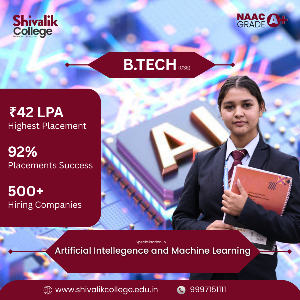


🎨 Dominant Colors Detected (RGB):


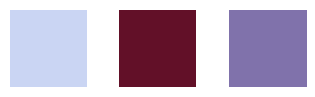

In [4]:
# Upload image from your PC
uploaded = files.upload()

for filename in uploaded.keys():
    # Run the audit function on the uploaded image
    final_score, feedback, colors = run_creative_audit(filename)

    # Display Dominant Colors
    print("\n🎨 Dominant Colors Detected (RGB):")
    fig, ax = plt.subplots(1, len(colors), figsize=(4, 1))
    for i, color in enumerate(colors):
        color_img = np.zeros((100, 100, 3), dtype=np.uint8)
        color_img[:] = color
        ax[i].imshow(color_img)
        ax[i].axis('off')
    plt.show()